In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Importamos tu función de limpieza de datos tal cual está en tu script
from Processing_RF import load_and_preprocess_data

print("1. Cargando y procesando datos...")
X_train, X_test, y_train, y_test, scaler, feature_names = load_and_preprocess_data()
print("Datos cargados correctamente.")

1. Cargando y procesando datos...


Datos cargados correctamente.


In [2]:
# Definir la ruta actual del notebook (carpeta Random_Forest)
CURRENT_DIR = os.getcwd()

print("2. Cargando el modelo optimizado guardado...")
# Cargamos el modelo en lugar de volver a hacer el Grid Search
best_rf = joblib.load(os.path.join(CURRENT_DIR, 'random_forest_optimizado.pkl'))
print("¡Modelo cargado con éxito!")

2. Cargando el modelo optimizado guardado...
¡Modelo cargado con éxito!


In [3]:
print("3. Aplicando ajuste de Umbral (Threshold Moving)...")

# Obtenemos las PROBABILIDADES de que sea clase 1 (Impago), no la predicción final
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Definimos nuestro nuevo umbral más estricto
NUEVO_UMBRAL = 0.35

# Si la probabilidad es mayor o igual a 0.35, lo marcamos como 1, si no, como 0.
y_pred_custom = (y_prob >= NUEVO_UMBRAL).astype(int)

# ==========================================
# EVALUACIÓN DEL MODELO OPTIMIZADO
# ==========================================
print(f"\n=== MÉTRICAS DEL MODELO OPTIMIZADO (Umbral {NUEVO_UMBRAL}) ===")
print(f"Recall (Sensibilidad) : {recall_score(y_test, y_pred_custom):.4f} <- ¡Mira cómo subió!")
print(f"F1-Score              : {f1_score(y_test, y_pred_custom):.4f}")
print(f"AUC-ROC               : {roc_auc_score(y_test, y_prob):.4f}")
print("\n--- Nuevo Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_custom))

3. Aplicando ajuste de Umbral (Threshold Moving)...

=== MÉTRICAS DEL MODELO OPTIMIZADO (Umbral 0.35) ===
Recall (Sensibilidad) : 0.7973 <- ¡Mira cómo subió!
F1-Score              : 0.4756
AUC-ROC               : 0.7743

--- Nuevo Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.91      0.56      0.69      4673
           1       0.34      0.80      0.48      1327

    accuracy                           0.61      6000
   macro avg       0.62      0.68      0.58      6000
weighted avg       0.78      0.61      0.64      6000



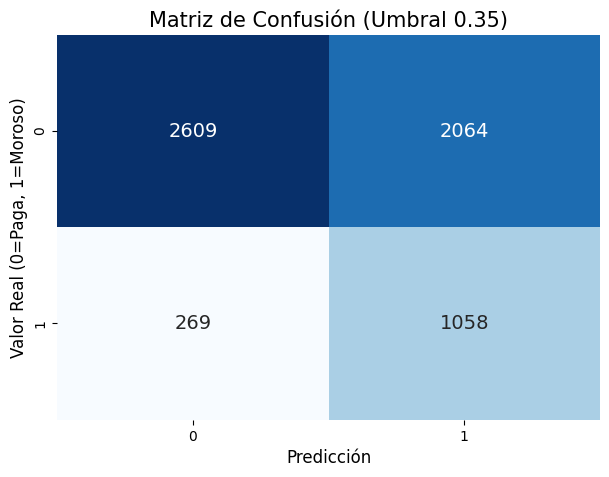


--- Impacto de Negocio ---
Morosos detectados correctamente (Verdaderos Positivos): 1058 de 1327
Morosos que se escaparon (Falsos Negativos): 269


In [4]:
# Generamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Matriz de Confusión (Umbral {NUEVO_UMBRAL})', fontsize=15)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real (0=Paga, 1=Moroso)', fontsize=12)
plt.show()

# Extraemos los valores para mostrar el impacto de negocio tal como lo tenías
tn, fp, fn, tp = cm.ravel()
print("\n--- Impacto de Negocio ---")
print(f"Morosos detectados correctamente (Verdaderos Positivos): {tp} de {tp+fn}")
print(f"Morosos que se escaparon (Falsos Negativos): {fn}")

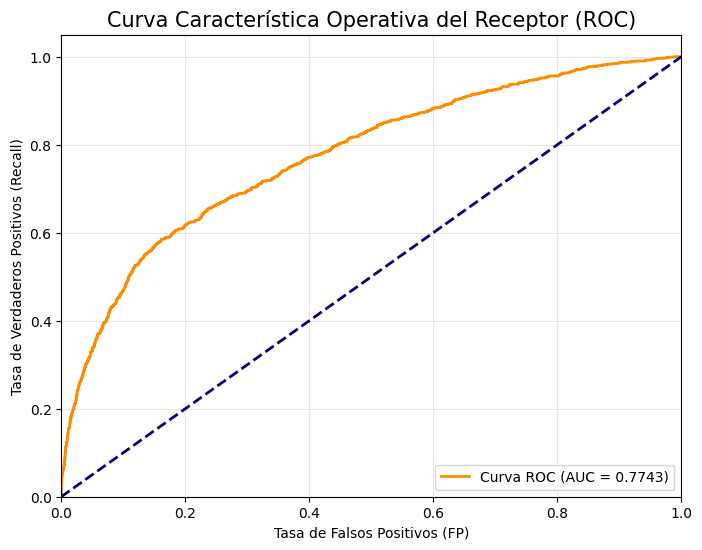

In [5]:
# Generamos la Curva ROC para ver el rendimiento general del modelo
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FP)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva Característica Operativa del Receptor (ROC)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

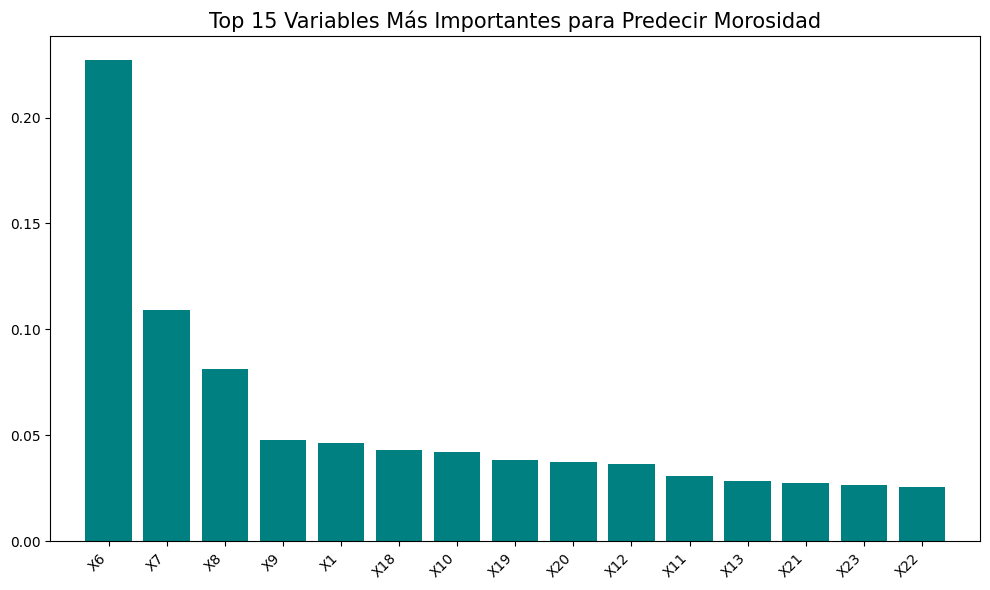

In [6]:
# Extraemos qué variables fueron más importantes para el modelo al predecir el riesgo
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Tomamos solo las 15 variables más importantes para que el gráfico sea legible
top_n = 15
top_indices = indices[:top_n]
top_features = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(10,6))
plt.title(f"Top {top_n} Variables Más Importantes para Predecir Morosidad", fontsize=15)
plt.bar(range(top_n), top_importances, align="center", color='teal')
plt.xticks(range(top_n), top_features, rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()